# CNN Development on Custom Dataset

## Objective
The objective of this assignment is to design, train, and evaluate a custom Convolutional Neural Network (CNN) for multi-class image classification.

## Dataset Source
For this assignment, I selected a multi-class image dataset from **Mendeley Data**.
Although the dataset was not created by me, I selected it, organized it, preprocessed it, and used it for CNN training and evaluation.



In [1]:
# =========================
# Import Required Libraries
# =========================

# For file and folder operations
import os
import shutil
import zipfile
import copy
import random

# For numerical operations and data handling
import numpy as np
import pandas as pd

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch core libraries
import torch
import torch.nn as nn
import torch.optim as optim

# Learning rate scheduler
from torch.optim import lr_scheduler

# Data loading utilities
from torch.utils.data import DataLoader

# Torchvision utilities for datasets and transforms
from torchvision import datasets, transforms

# Evaluation metrics from scikit-learn
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =========================
# Set Random Seed
# =========================

# If someone runs the same code again, the result will be more consistent.
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# =========================
# Select Device
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Print the selected device
print("Using device:", device)

Using device: cuda


## 1. Dataset Preparation

In this section, the dataset will be prepared for training, validation, and testing.

The original dataset was collected from **Mendeley Data** and then reorganized into:
- Training set
- Validation set
- Test set

This step is important because proper dataset organization is required before training a CNN model.

In [5]:
# ==========================================
# Extract the uploaded dataset zip file
# ==========================================



zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("archive.zip extracted successfully.")

archive.zip extracted successfully.


## 2. Organize the Dataset into Train, Validation, and Test Sets

After extracting the dataset, the class folders are reorganized into a standard structure for CNN training.

In this project, the dataset is divided into:
- **70% Training set**
- **15% Validation set**
- **15% Test set**

This split helps train the model, monitor validation performance during training, and finally evaluate the model on unseen test data.

In [8]:
# =====================================================
# Reorganize the dataset into train / val / test splits
# =====================================================

# Main source folder where the extracted class folders are stored
source_dir = "/content"

# New folder where the final organized dataset will be saved
dest_dir = "/content/dataset"

# Original folder names to  cleaner class names
mapping = {
    "fresh_peaches_done": "peach_fresh",
    "rotten_peaches_done": "peach_rotten",
    "fresh_strawberries_done": "strawberry_fresh",
    "rotten_strawberries_done": "strawberry_rotten",
    "fresh_pomegranates_done": "pomegranate_fresh",
    "rotten_pomegranates_done": "pomegranate_rotten"
}


if os.path.exists(dest_dir):
    shutil.rmtree(dest_dir)

# Create  folders for train, validation, and test
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(dest_dir, split), exist_ok=True)

# This list for  class-wise image counts //badhan
split_summary = []

for old_name, new_name in mapping.items():
    folder_path = os.path.join(source_dir, old_name)

    # Check if  the folder exists
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        continue

    # Keep only image files
    files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Sort and shuffle  before splitting
    files = sorted(files)
    random.shuffle(files)

    # divided 70% train, 15% validation, 15% test
    train_end = int(len(files) * 0.70)
    val_end = int(len(files) * 0.85)

    train_files = files[:train_end]
    val_files = files[train_end:val_end]
    test_files = files[val_end:]

    # Copy files into the new folder structure
    for split_name, split_files in zip(
        ["train", "val", "test"],
        [train_files, val_files, test_files]
    ):
        class_dir = os.path.join(dest_dir, split_name, new_name)
        os.makedirs(class_dir, exist_ok=True)

        for file_name in split_files:
            src_path = os.path.join(folder_path, file_name)
            dst_path = os.path.join(class_dir, file_name)
            shutil.copy2(src_path, dst_path)

    # Save summary for this class
    split_summary.append({
        "Class": new_name,
        "Train": len(train_files),
        "Validation": len(val_files),
        "Test": len(test_files),
        "Total": len(files)
    })

print("Dataset has been organized successfully.")

Dataset has been organized successfully.


In [9]:
# ==========================================
# Show class-wise split summary
# ==========================================

#check data spliting

split_df = pd.DataFrame(split_summary)
split_df

,Class,Train,Validation,Test,Total
0,peach_fresh,175,37,38,250
1,peach_rotten,240,51,52,343
2,strawberry_fresh,175,37,38,250
3,strawberry_rotten,175,38,38,251
4,pomegranate_fresh,217,47,47,311
5,pomegranate_rotten,175,37,38,250


## 3. Load the Dataset Using PyTorch

After organizing the dataset into training, validation, and test folders, the next step is to load the dataset using PyTorch.

In this section:
- image preprocessing is applied
- training data augmentation is used
- `ImageFolder` is used to read the dataset
- `DataLoader` is used to create mini-batches for training and evaluation

This step is important because CNN models require properly transformed image tensors as input.

In [10]:
# =====================================================
# Define image transformations for training and testing
# =====================================================

# Training transform:
# I am using a few simple augmentation techniques here
# so that the model can generalize better during training.
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Validation and test transform:
# Here I am not using random augmentation.
# I only resize and normalize the images.
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Path of the organized dataset
data_dir = "/content/dataset"

# Load datasets using ImageFolder
train_dataset = datasets.ImageFolder(
    os.path.join(data_dir, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(data_dir, "val"),
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(data_dir, "test"),
    transform=test_transform
)

# Set batch size
batch_size = 32

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Save class names and number of classes
class_names = train_dataset.classes
num_classes = len(class_names)

print("Datasets and DataLoaders created successfully.")

Datasets and DataLoaders created successfully.


In [11]:
# ==========================================
# Show basic dataset information
# ==========================================

# This section helps verify that the dataset
# was loaded correctly using PyTorch.

print("Class names:")
print(class_names)
print()

print("Number of classes:", num_classes)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))
print()

# Check one batch shape
images, labels = next(iter(train_loader))

print("One training batch image shape:", images.shape)
print("One training batch label shape:", labels.shape)

Class names:
['peach_fresh', 'peach_rotten', 'pomegranate_fresh', 'pomegranate_rotten', 'strawberry_fresh', 'strawberry_rotten']

Number of classes: 6
Training samples: 1157
Validation samples: 247
Test samples: 251

One training batch image shape: torch.Size([32, 3, 128, 128])
One training batch label shape: torch.Size([32])


## 4. Explore the Dataset

Before defining the CNN architecture, I explored the dataset to better understand the image classes and their distribution.

In this section:
- a few sample training images are displayed
- the class distribution is visualized

This step is useful because it helps verify that the dataset was loaded correctly and gives a better idea about the classification problem.

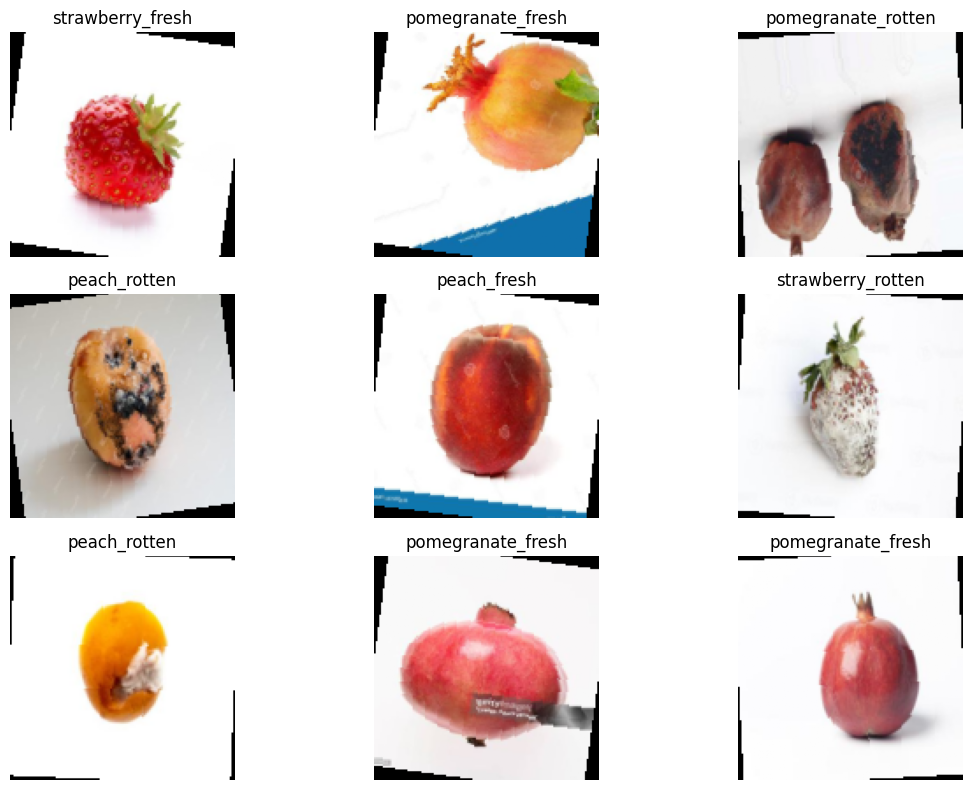

In [12]:
# ==========================================
# Show some sample images from the training set
# ==========================================

# This function converts a normalized tensor image
# back to a displayable image.
def show_image(img):
    img = img / 2 + 0.5   # unnormalize the image
    np_img = img.numpy()
    plt.imshow(np.transpose(np_img, (1, 2, 0)))
    plt.axis("off")

# Take one batch from the training loader
images, labels = next(iter(train_loader))

# Show a few sample images
plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    show_image(images[i].cpu())
    plt.title(class_names[labels[i].item()])

plt.tight_layout()
plt.show()

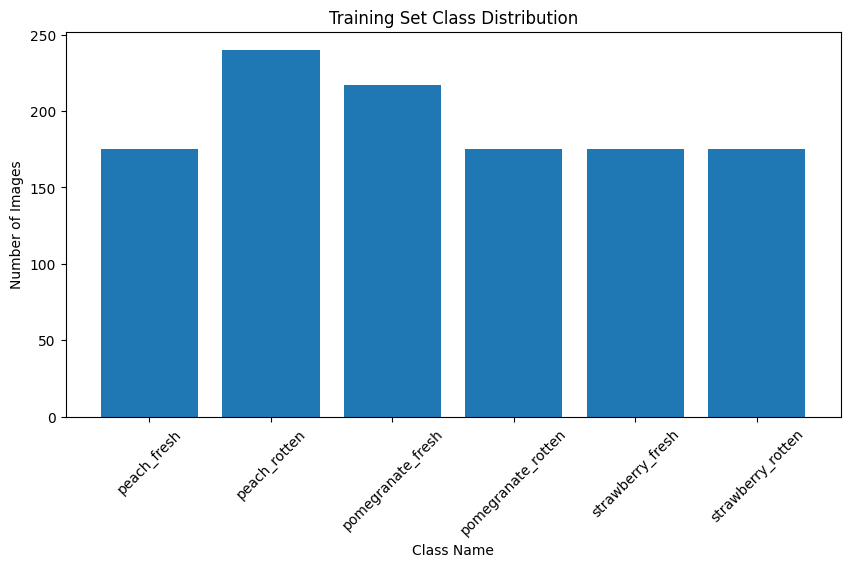

peach_fresh: 175
peach_rotten: 240
pomegranate_fresh: 217
pomegranate_rotten: 175
strawberry_fresh: 175
strawberry_rotten: 175


In [13]:
# ==========================================
# Plot class-wise image distribution
# ==========================================

# This section counts how many images are present
# in each class of the training set.

train_class_counts = [0] * num_classes

for _, label in train_dataset.samples:
    train_class_counts[label] += 1

# Create a simple bar chart
plt.figure(figsize=(10, 5))
plt.bar(class_names, train_class_counts)

plt.title("Training Set Class Distribution")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

# Also print the counts clearly
for class_name, count in zip(class_names, train_class_counts):
    print(f"{class_name}: {count}")

## 5. Define CNN Architecture

According to the assignment requirements, I implemented a custom CNN model for multi-class image classification.

In this section, I define two models:

1. **SimpleCNN**  
   A basic CNN model without Batch Normalization and Dropout.

2. **RegularizedCNN**  
   A CNN model with Batch Normalization and Dropout to reduce overfitting and improve generalization.

This comparison will help analyze whether regularization improves model performance on the fruit dataset.

In [14]:
# ==========================================
# Define a simple baseline CNN model
# ==========================================

# This model does not use Batch Normalization or Dropout.
# I am keeping it simple so that later I can compare it
# with a regularized version of the CNN.

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        # Feature extraction part
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Classification part
        # Input image size = 128x128
        # After 3 max pooling layers -> 16x16
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # Pass input through convolution layers
        x = self.features(x)

        # Pass extracted features through fully connected layers
        x = self.classifier(x)

        return x

In [15]:
# ==========================================
# Define a regularized CNN model
# ==========================================

# This model uses Batch Normalization and Dropout.
# I am using this model to check whether regularization
# can improve validation and test performance.

class RegularizedCNN(nn.Module):
    def __init__(self, num_classes):
        super(RegularizedCNN, self).__init__()

        # Feature extraction part with Batch Normalization
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Classification part with Dropout
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # Pass input through convolution layers
        x = self.features(x)

        # Pass extracted features through fully connected layers
        x = self.classifier(x)

        return x


# Create both models and move them to GPU/CPU
simple_model = SimpleCNN(num_classes).to(device)
regularized_model = RegularizedCNN(num_classes).to(device)

print("Simple CNN Model:\n")
print(simple_model)

print("\n" + "=" * 70 + "\n")

print("Regularized CNN Model:\n")
print(regularized_model)

Simple CNN Model:

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=6, bias=True)
  )
)


Regularized CNN Model:

RegularizedCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=

## 6. Architecture Summary and Design Justification

To better understand the structure of the implemented CNN models, a detailed model summary is shown below.

### Design Justification
The CNN architecture was designed with three convolutional blocks so that the model can gradually learn low-level, mid-level, and high-level image features.

- **Convolution layers** are used to extract important visual patterns from the fruit images.
- **ReLU activation** introduces non-linearity so that the model can learn more complex patterns.
- **MaxPooling layers** reduce spatial size and computation while keeping the most important features.
- **Batch Normalization** is used in the regularized model to make training more stable.
- **Dropout** is used in the regularized model to reduce overfitting.
- **Fully connected layers** are used at the end to perform final classification into 6 classes.

The input image size was fixed at **128 × 128**, which gives a good balance between training speed and visual information.

In [16]:
# ==========================================
# Show detailed model summary
# ==========================================

# I am using torchinfo here to display a more detailed
# summary of both CNN models, including input and output shapes.

!pip install -q torchinfo

from torchinfo import summary

print("Detailed Summary of Simple CNN\n")
summary(simple_model, input_size=(32, 3, 128, 128))

print("\n" + "=" * 80 + "\n")

print("Detailed Summary of Regularized CNN\n")
summary(regularized_model, input_size=(32, 3, 128, 128))

Detailed Summary of Simple CNN



Detailed Summary of Regularized CNN



Layer (type:depth-idx)                   Output Shape              Param #
RegularizedCNN                           [32, 6]                   --
├─Sequential: 1-1                        [32, 128, 16, 16]         --
│    └─Conv2d: 2-1                       [32, 32, 128, 128]        896
│    └─BatchNorm2d: 2-2                  [32, 32, 128, 128]        64
│    └─ReLU: 2-3                         [32, 32, 128, 128]        --
│    └─MaxPool2d: 2-4                    [32, 32, 64, 64]          --
│    └─Conv2d: 2-5                       [32, 64, 64, 64]          18,496
│    └─BatchNorm2d: 2-6                  [32, 64, 64, 64]          128
│    └─ReLU: 2-7                         [32, 64, 64, 64]          --
│    └─MaxPool2d: 2-8                    [32, 64, 32, 32]          --
│    └─Conv2d: 2-9                       [32, 128, 32, 32]         73,856
│    └─BatchNorm2d: 2-10                 [32, 128, 32, 32]         256
│    └─ReLU: 2-11                        [32, 128, 32, 32]         --
│   

## 7. Hyperparameter Details and Rationale

The following hyperparameters were used in this experiment:

- **Image size:** 128 × 128
- **Batch size:** 32
- **Number of classes:** 6
- **Optimizer:** Adam
- **Learning rate:** 0.001
- **Loss function:** CrossEntropyLoss
- **Scheduler:** StepLR
- **Epochs:** 10
- **Dropout rate:** 0.5 in the regularized CNN

### Rationale
These values were selected to keep the training process simple, stable, and effective.

- A **128 × 128** image size was used to reduce computational cost while still keeping enough visual detail.
- A **batch size of 32** gives a good balance between memory usage and stable gradient updates.
- **Adam optimizer** was selected because it usually converges faster and works well for image classification tasks.
- **CrossEntropyLoss** is appropriate for multi-class classification problems.
- **StepLR scheduler** will later help reduce the learning rate during training for better optimization.
- A **dropout rate of 0.5** was used in the regularized model to help reduce overfitting.

## 8. Training Setup

In this section, I am preparing the training configuration for both CNN models.

The following components will be used:
- CrossEntropyLoss as the loss function
- Adam as the optimizer
- StepLR as the learning rate scheduler

I will also define a reusable training function so that both models can be trained in the same way.

In [18]:
# ==========================================
# Define loss function, optimizer, and scheduler
# ==========================================

# CrossEntropyLoss is suitable for multi-class classification.
criterion = nn.CrossEntropyLoss()

# Optimizer and scheduler for the simple CNN
optimizer_simple = optim.Adam(simple_model.parameters(), lr=0.001)
scheduler_simple = lr_scheduler.StepLR(
    optimizer_simple,
    step_size=5,
    gamma=0.1
)

# Optimizer and scheduler for the regularized CNN
optimizer_regularized = optim.Adam(regularized_model.parameters(), lr=0.001)
scheduler_regularized = lr_scheduler.StepLR(
    optimizer_regularized,
    step_size=5,
    gamma=0.1
)

print("Training setup created successfully.")

Training setup created successfully.


In [20]:

# ==========================================
# Define the training function
# ==========================================

# This function will train the model and also
# check validation performance after each epoch.

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    # I am saving the best model weights based on validation accuracy
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    # These lists will store loss and accuracy values
    # so that I can plot them later
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    # Loop through all epochs
    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 40)

        # =========================
        # Training phase
        # =========================
        model.train()

        running_train_loss = 0.0
        running_train_correct = 0

        for images, labels in train_loader:
            # Move images and labels to GPU or CPU
            images = images.to(device)
            labels = labels.to(device)

            # Clear old gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            # Compute training loss
            loss = criterion(outputs, labels)

            # Backward pass and weight update
            loss.backward()
            optimizer.step()

            # Add current batch loss and correct predictions
            running_train_loss += loss.item() * images.size(0)
            running_train_correct += torch.sum(preds == labels.data)

        # Calculate average training loss and accuracy
        epoch_train_loss = running_train_loss / len(train_dataset)
        epoch_train_acc = running_train_correct.double().item() / len(train_dataset)

        # =========================
        # Validation phase
        # =========================
        model.eval()

        running_val_loss = 0.0
        running_val_correct = 0

        with torch.no_grad():
            for images, labels in val_loader:
                # Move images and labels to GPU or CPU
                images = images.to(device)
                labels = labels.to(device)

                # Forward pass
                outputs = model(images)
                _, preds = torch.max(outputs, 1)

                # Compute validation loss
                loss = criterion(outputs, labels)

                # Add current batch loss and correct predictions
                running_val_loss += loss.item() * images.size(0)
                running_val_correct += torch.sum(preds == labels.data)

        # Calculate average validation loss and accuracy
        epoch_val_loss = running_val_loss / len(val_dataset)
        epoch_val_acc = running_val_correct.double().item() / len(val_dataset)

        # Save results for later plotting
        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_acc"].append(epoch_val_acc)

        # Print epoch results
        print(f"Train Loss: {epoch_train_loss:.4f} | Train Accuracy: {epoch_train_acc:.4f}")
        print(f"Val Loss:   {epoch_val_loss:.4f} | Val Accuracy:   {epoch_val_acc:.4f}")

        # Save the best model according to validation accuracy
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        # Update learning rate
        scheduler.step()
        print()

    # Load the best model weights before returning
    model.load_state_dict(best_model_wts)

    print(f"Best Validation Accuracy: {best_val_acc:.4f}")

    return model, history, best_val_acc



In [21]:
# ==========================================
# Train the Simple CNN model
# ==========================================

# Here I am training the baseline CNN model first.
# Later I will compare its performance with the regularized CNN.

simple_model, simple_history, simple_best_val_acc = train_model(
    model=simple_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_simple,
    scheduler=scheduler_simple,
    num_epochs=10
)

Epoch 1/10
----------------------------------------
Train Loss: 1.6469 | Train Accuracy: 0.3034
Val Loss:   1.2656 | Val Accuracy:   0.4656

Epoch 2/10
----------------------------------------
Train Loss: 1.1141 | Train Accuracy: 0.5782
Val Loss:   1.0027 | Val Accuracy:   0.6275

Epoch 3/10
----------------------------------------
Train Loss: 0.9274 | Train Accuracy: 0.6569
Val Loss:   0.9440 | Val Accuracy:   0.6842

Epoch 4/10
----------------------------------------
Train Loss: 0.7598 | Train Accuracy: 0.7200
Val Loss:   0.8571 | Val Accuracy:   0.7085

Epoch 5/10
----------------------------------------
Train Loss: 0.7508 | Train Accuracy: 0.7252
Val Loss:   0.9452 | Val Accuracy:   0.6518

Epoch 6/10
----------------------------------------
Train Loss: 0.6777 | Train Accuracy: 0.7666
Val Loss:   0.7283 | Val Accuracy:   0.7490

Epoch 7/10
----------------------------------------
Train Loss: 0.5888 | Train Accuracy: 0.7917
Val Loss:   0.7289 | Val Accuracy:   0.7449

Epoch 8/10
--

In [22]:
# ==========================================
# Train the Regularized CNN model
# ==========================================

# Now I am training the CNN model with
# Batch Normalization and Dropout.

regularized_model, regularized_history, regularized_best_val_acc = train_model(
    model=regularized_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_regularized,
    scheduler=scheduler_regularized,
    num_epochs=10
)

Epoch 1/10
----------------------------------------
Train Loss: 3.9218 | Train Accuracy: 0.2990
Val Loss:   1.4700 | Val Accuracy:   0.4777

Epoch 2/10
----------------------------------------
Train Loss: 1.4268 | Train Accuracy: 0.4322
Val Loss:   1.1979 | Val Accuracy:   0.5911

Epoch 3/10
----------------------------------------
Train Loss: 1.3111 | Train Accuracy: 0.4538
Val Loss:   1.1874 | Val Accuracy:   0.6073

Epoch 4/10
----------------------------------------
Train Loss: 1.2814 | Train Accuracy: 0.4883
Val Loss:   1.0722 | Val Accuracy:   0.6316

Epoch 5/10
----------------------------------------
Train Loss: 1.1781 | Train Accuracy: 0.5177
Val Loss:   0.9330 | Val Accuracy:   0.6680

Epoch 6/10
----------------------------------------
Train Loss: 1.0341 | Train Accuracy: 0.5903
Val Loss:   0.8629 | Val Accuracy:   0.7085

Epoch 7/10
----------------------------------------
Train Loss: 0.9987 | Train Accuracy: 0.6076
Val Loss:   0.8149 | Val Accuracy:   0.7085

Epoch 8/10
--

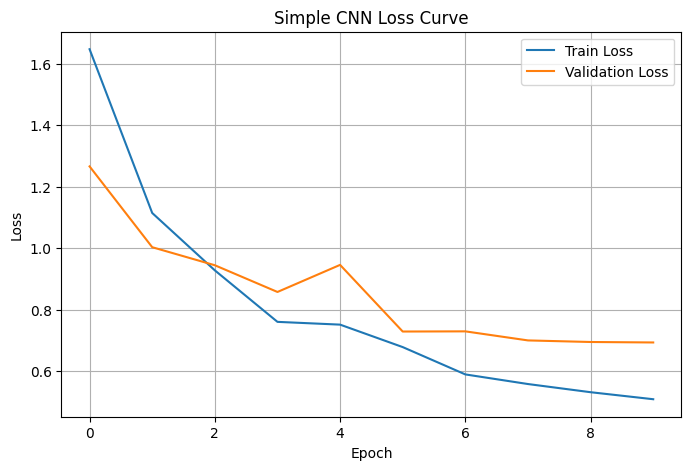

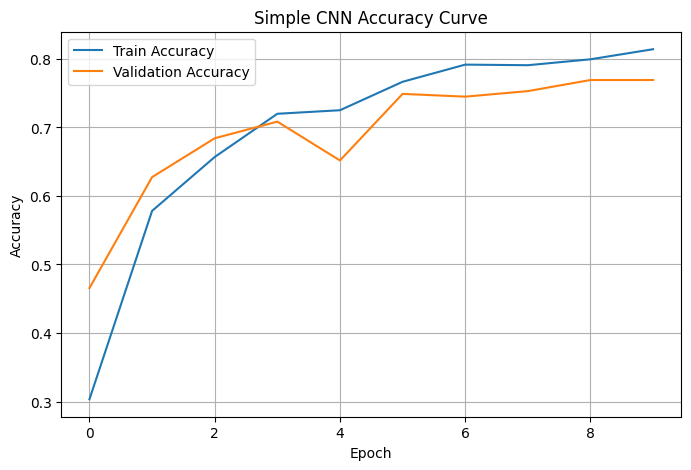

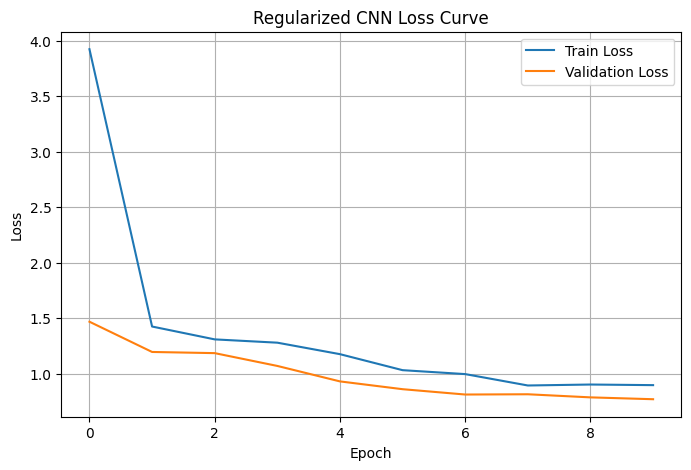

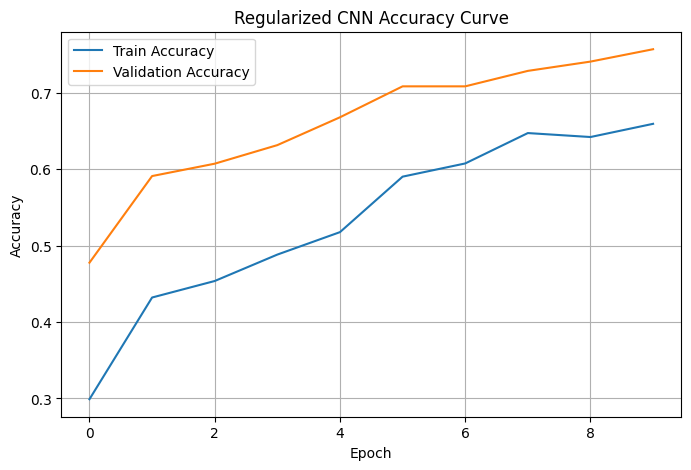

In [25]:
# ==========================================
# Plot training and validation curves
# ==========================================

# This function will plot loss and accuracy curves
# for a trained model.

def plot_history(history, model_name):
    # Plot loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot accuracy curve
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"], label="Validation Accuracy")
    plt.title(f"{model_name} Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot curves for both models
plot_history(simple_history, "Simple CNN")
plot_history(regularized_history, "Regularized CNN")

## 9. Evaluate the Model on the Test Set

After training both CNN models, the next step is to evaluate their performance on the unseen test set.

In this section, I will calculate:
- Accuracy
- Precision
- Recall
- F1-score
- Classification report
- Confusion matrix

This evaluation is important because it shows how well the trained models generalize to new images.

In [27]:
# ==========================================
# Define the evaluation function for test set
# ==========================================

# This function will evaluate a trained model on the test set.
# It will calculate overall metrics, classification report,
# confusion matrix, and best/worst performing classes.

def evaluate_model(model, test_loader, class_names, model_name):
    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in test_loader:
            # Move images and labels to GPU or CPU
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            # Store true labels and predicted labels
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    # =========================
    # Overall evaluation metrics
    # =========================
    test_accuracy = accuracy_score(all_labels, all_preds)
    test_precision = precision_score(all_labels, all_preds, average="weighted")
    test_recall = recall_score(all_labels, all_preds, average="weighted")
    test_f1 = f1_score(all_labels, all_preds, average="weighted")

    print(f"Results for {model_name}")
    print("-" * 50)
    print(f"Test Accuracy : {test_accuracy:.4f}")
    print(f"Precision     : {test_precision:.4f}")
    print(f"Recall        : {test_recall:.4f}")
    print(f"F1-score      : {test_f1:.4f}")
    print()

    # =========================
    # Classification report
    # =========================
    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        output_dict=True
    )

    report_df = pd.DataFrame(report).transpose()
    print("Classification Report:")
    display(report_df)

    # =========================
    # Confusion matrix
    # =========================
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

    # =========================
    # Best and worst class analysis
    # =========================
    class_f1_scores = {}

    for class_name in class_names:
        class_f1_scores[class_name] = report[class_name]["f1-score"]

    best_class = max(class_f1_scores, key=class_f1_scores.get)
    worst_class = min(class_f1_scores, key=class_f1_scores.get)

    print("Best Performing Class :", best_class, f"({class_f1_scores[best_class]:.4f})")
    print("Worst Performing Class:", worst_class, f"({class_f1_scores[worst_class]:.4f})")

    return {
        "model_name": model_name,
        "accuracy": test_accuracy,
        "precision": test_precision,
        "recall": test_recall,
        "f1_score": test_f1,
        "best_class": best_class,
        "best_class_f1": class_f1_scores[best_class],
        "worst_class": worst_class,
        "worst_class_f1": class_f1_scores[worst_class],
        "report_df": report_df
    }



Results for Simple CNN
--------------------------------------------------
Test Accuracy : 0.7450
Precision     : 0.7472
Recall        : 0.7450
F1-score      : 0.7386

Classification Report:


,precision,recall,f1-score,support
peach_fresh,0.785714,0.868421,0.825000,38.00000
peach_rotten,0.690909,0.730769,0.710280,52.00000
pomegranate_fresh,0.844444,0.808511,0.826087,47.00000
pomegranate_rotten,0.695652,0.421053,0.524590,38.00000
strawberry_fresh,0.810811,0.789474,0.800000,38.00000
strawberry_rotten,0.653061,0.842105,0.735632,38.00000
accuracy,0.745020,0.745020,0.745020,0.74502
macro avg,0.746765,0.743389,0.736932,251.00000
weighted avg,0.747152,0.745020,0.738642,251.00000


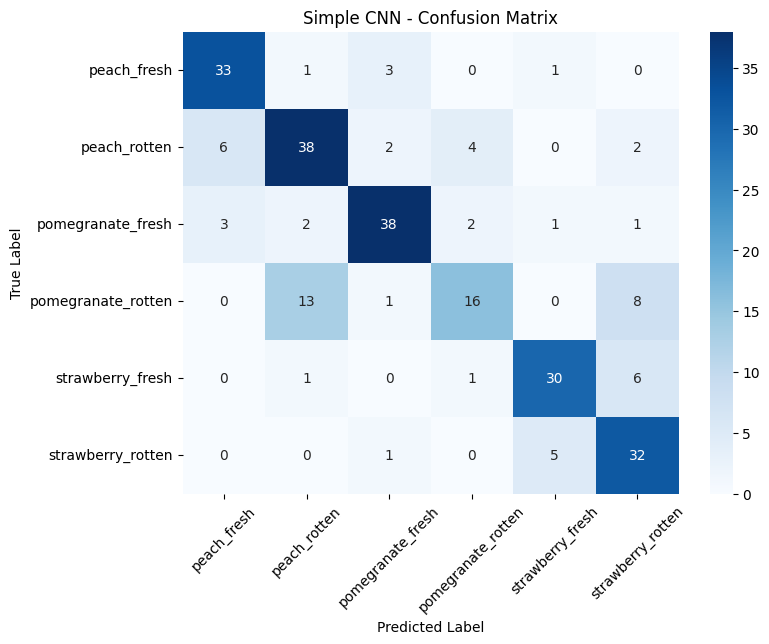

Best Performing Class : pomegranate_fresh (0.8261)
Worst Performing Class: pomegranate_rotten (0.5246)


In [28]:
# ==========================================
# Evaluate the Simple CNN on the test set
# ==========================================

simple_results = evaluate_model(
    model=simple_model,
    test_loader=test_loader,
    class_names=class_names,
    model_name="Simple CNN"
)

Results for Regularized CNN
--------------------------------------------------
Test Accuracy : 0.7530
Precision     : 0.7608
Recall        : 0.7530
F1-score      : 0.7488

Classification Report:


,precision,recall,f1-score,support
peach_fresh,0.783784,0.763158,0.773333,38.000000
peach_rotten,0.627119,0.711538,0.666667,52.000000
pomegranate_fresh,0.854167,0.872340,0.863158,47.000000
pomegranate_rotten,0.739130,0.447368,0.557377,38.000000
strawberry_fresh,0.914286,0.842105,0.876712,38.000000
strawberry_rotten,0.673469,0.868421,0.758621,38.000000
accuracy,0.752988,0.752988,0.752988,0.752988
macro avg,0.765326,0.750822,0.749311,251.000000
weighted avg,0.760803,0.752988,0.748784,251.000000


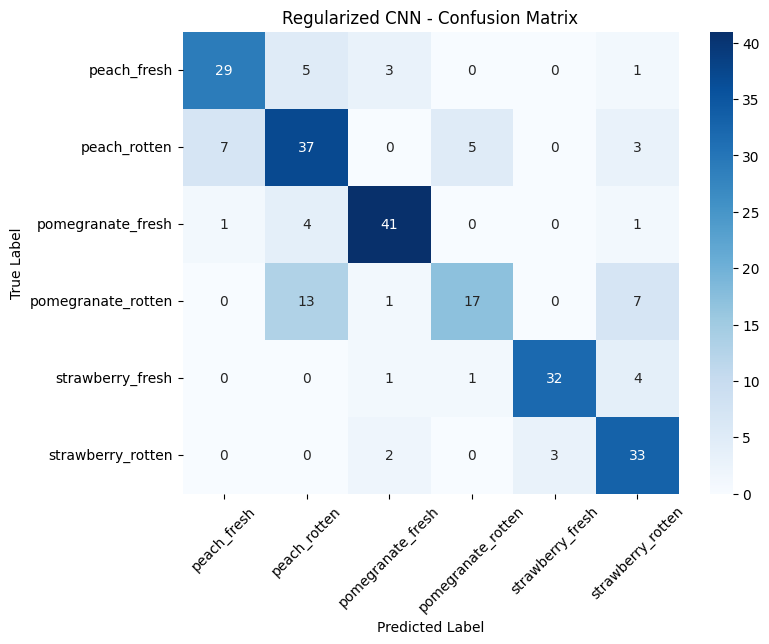

Best Performing Class : strawberry_fresh (0.8767)
Worst Performing Class: pomegranate_rotten (0.5574)


In [29]:
# ==========================================
# Evaluate the Regularized CNN on the test set
# ==========================================

regularized_results = evaluate_model(
    model=regularized_model,
    test_loader=test_loader,
    class_names=class_names,
    model_name="Regularized CNN"
)

In [30]:
# ==========================================
# Compare both models in one summary table
# ==========================================

# This table will help compare the final test performance
# of the Simple CNN and Regularized CNN side by side.

comparison_df = pd.DataFrame([
    {
        "Model": simple_results["model_name"],
        "Accuracy": simple_results["accuracy"],
        "Precision": simple_results["precision"],
        "Recall": simple_results["recall"],
        "F1-score": simple_results["f1_score"],
        "Best Class": simple_results["best_class"],
        "Worst Class": simple_results["worst_class"]
    },
    {
        "Model": regularized_results["model_name"],
        "Accuracy": regularized_results["accuracy"],
        "Precision": regularized_results["precision"],
        "Recall": regularized_results["recall"],
        "F1-score": regularized_results["f1_score"],
        "Best Class": regularized_results["best_class"],
        "Worst Class": regularized_results["worst_class"]
    }
])

comparison_df

,Model,Accuracy,Precision,Recall,F1-score,Best Class,Worst Class
0,Simple CNN,0.745020,0.747152,0.745020,0.738642,pomegranate_fresh,pomegranate_rotten
1,Regularized CNN,0.752988,0.760803,0.752988,0.748784,strawberry_fresh,pomegranate_rotten


## 10. Analysis and Discussion of Results

In this experiment, both a Simple CNN and a Regularized CNN were trained and evaluated on the same fruit image dataset.

From the final test results, the **Regularized CNN** performed slightly better overall than the **Simple CNN**.

### Model Comparison
- **Simple CNN**
  - Accuracy: **0.7450**
  - Precision: **0.7472**
  - Recall: **0.7450**
  - F1-score: **0.7386**

- **Regularized CNN**
  - Accuracy: **0.7530**
  - Precision: **0.7608**
  - Recall: **0.7530**
  - F1-score: **0.7488**

This shows that the model with **Batch Normalization and Dropout** achieved slightly better generalization on the test set.

### Best and Worst Performing Classes
For the **Simple CNN**:
- Best performing class: **pomegranate_fresh**
- Worst performing class: **pomegranate_rotten**

For the **Regularized CNN**:
- Best performing class: **strawberry_fresh**
- Worst performing class: **pomegranate_rotten**

This means both models struggled most with **pomegranate_rotten**, which may be due to visual similarity with other rotten fruit classes, color changes, or less clear texture patterns.

### Confusion Matrix Observation
From the confusion matrices, it can be observed that some rotten fruit classes were confused with other rotten categories.  
This suggests that the CNN learned the general idea of fruit freshness, but still faced difficulty when different rotten fruits had similar visual appearance.

### Overall Discussion
The Simple CNN learned faster and showed strong validation performance.  
However, the Regularized CNN produced slightly better final test metrics, which suggests that regularization helped improve generalization.

Therefore, based on the final test set performance, the **Regularized CNN** can be considered the better final model for this assignment.

In [31]:
# ==========================================
# Select the best final model and save it
# ==========================================

# Here I am selecting the final model based on test accuracy.
# The model with better test accuracy will be saved.

if regularized_results["accuracy"] > simple_results["accuracy"]:
    best_model = regularized_model
    best_model_name = "Regularized CNN"
    best_results = regularized_results
else:
    best_model = simple_model
    best_model_name = "Simple CNN"
    best_results = simple_results

print("Best Final Model:", best_model_name)
print(f"Test Accuracy: {best_results['accuracy']:.4f}")

# Save the best model weights
torch.save(best_model.state_dict(), "best_cnn_model.pth")

print("Best model weights saved as: best_cnn_model.pth")

Best Final Model: Regularized CNN
Test Accuracy: 0.7530
Best model weights saved as: best_cnn_model.pth


## 11. Conclusion

In this assignment, I developed and evaluated two custom CNN models for multi-class fruit image classification.

The dataset was collected from Mendeley Data, then reorganized into training, validation, and test sets before training.

Two different CNN architectures were tested:
- a Simple CNN
- a Regularized CNN with Batch Normalization and Dropout

From the final test results, the Regularized CNN achieved slightly better performance than the Simple CNN.  
This suggests that regularization helped improve the model's ability to generalize on unseen test images.

Overall, this experiment shows that a custom CNN can perform effectively on a fruit freshness classification task when proper preprocessing, training, and evaluation steps are followed.

## 12. Future Work

Although the model performed reasonably well, there is still room for improvement.

In future work, the performance of this classification system can be improved by:
- training for more epochs
- using stronger data augmentation techniques
- tuning hyperparameters such as learning rate and dropout rate
- trying different optimizers such as SGD
- using early stopping
- applying transfer learning models such as ResNet18 or EfficientNet

These improvements may help the model achieve better generalization and higher classification accuracy on unseen test images.